# Analyse complète des motifs de rejet

Ce notebook :
1. charge les données de rejet ;
2. extrait les événements de rejet depuis l'historique ;
3. sépare les motifs en une ligne par motif ;
4. nettoie les textes sans perdre les actions importantes ;
5. explore les n-grammes ;
6. regroupe les motifs similaires ;
7. attribue des thèmes métier ;
8. génère un rapport Excel complet.

In [1]:
# À lancer uniquement si les bibliothèques ne sont pas déjà installées.
%pip install pandas openpyxl matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cellule taguée "parameters" (papermill) : ces valeurs peuvent être surchargées
# à l'exécution sans modifier le notebook.
#
# RUN_MODE = "notebook" : comportement interactif d'origine — lecture d'un export
#            Excel local (une ligne par dossier, historique multi-événements).
# RUN_MODE = "dagster"  : exécution automatisée côté ADAC — lecture directe de
#            marts.mart_digifor__motifs_rejet (dbt), déjà une ligne par événement
#            de rejet avec texte nettoyé.
RUN_MODE = "notebook"
OUTPUT_DIR = "../data/output"

In [3]:
# Cette cellule rassemble les bibliothèques et tous les paramètres modifiables.

import os

# Plafond des threads BLAS avant tout import scientifique : sans cela, un
# balayage KMeans/MiniBatchKMeans peut être jusqu'à 45x plus lent par
# sursouscription des threads (observé en conditions réelles sur ce notebook,
# un environnement Dagster/worker ayant plus de cœurs aggraverait le problème).
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")

from pathlib import Path
from collections import Counter
from io import BytesIO
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib

if RUN_MODE == "dagster":
    # Pas de serveur d'affichage dans un worker Dagster/papermill headless.
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering, MiniBatchKMeans
from sklearn.metrics import silhouette_score

from openpyxl import load_workbook
from openpyxl.drawing.image import Image as ExcelImage

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)
sns.set_theme(style="whitegrid", context="notebook")

# -----------------------------
# Fichiers d'entrée et de sortie
# -----------------------------
DATA_PATH = Path("../data/query_result.xlsx")
SHEET_NAME = "Résultats de la requête"

OUTPUT_DIR = Path(OUTPUT_DIR)
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_PATH = OUTPUT_DIR / "rejection_events.csv"
MOTIFS_PATH = OUTPUT_DIR / "rejection_reasons_detailed.csv"
REPORT_PATH = OUTPUT_DIR / "rapport_analyse_motifs_rejet.xlsx"

# -----------------------------
# Colonnes attendues dans l'export Excel (RUN_MODE == "notebook")
# -----------------------------
TARGET_COL = "Historique Rejets"
REGION_COL = "Region"
OPERATOR_COL = "Nom Operateur Court"

REQUIRED_COLUMNS = [
    TARGET_COL,
    REGION_COL,
    OPERATOR_COL,
    "Niveau",
    "Nb Occurrences Rejet",
    "Nb Dossiers Distincts",
]

# -----------------------------
# Mart source dbt/ADAC en RUN_MODE == "dagster"
# -----------------------------
MART_TABLE = "marts.mart_digifor__motifs_rejet"

# -----------------------------------------
# Paramètres de représentation par n-grammes
# -----------------------------------------
NGRAM_RANGE = (1, 3)   # mots seuls, bigrammes et trigrammes
MIN_DF = 3             # un n-gramme doit apparaître au moins 3 fois
MAX_DF = 0.90          # exclut les expressions présentes dans presque tous les motifs
N_CLUSTERS = 20        # repli utilisé uniquement si la méthode du coude ne peut pas être appliquée

# -----------------------------------------
# Paramètres de la méthode du coude (choix du nombre optimal de clusters)
# -----------------------------------------
# Le balayage utilise MiniBatchKMeans (rapide, adapté à un grand nombre de k
# testés sur une matrice TF-IDF dense) uniquement pour repérer le coude ;
# le clustering final reste AgglomerativeClustering avec ce k.
K_ELBOW_MIN = 8       # plus petite valeur de k testée
K_ELBOW_MAX = 80      # plus grande valeur de k testée
K_ELBOW_STEP = 4       # pas entre deux valeurs de k testées

DATE_FORMAT = "%d/%m/%Y %H:%M"

In [4]:
# Fonctions de normalisation générale.
# Elles sont utilisées à plusieurs étapes du notebook.

def strip_accents(text):
    """Supprime les accents pour rapprocher les variantes : signé / signe."""
    if pd.isna(text):
        return ""
    normalized = unicodedata.normalize("NFKD", str(text))
    return "".join(char for char in normalized if not unicodedata.combining(char))


def normalize_spaces(text):
    """Remplace les espaces, tabulations et retours ligne multiples par un espace."""
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


def safe_sheet_name(name):
    """Garantit un nom de feuille Excel valide et inférieur à 31 caractères."""
    return re.sub(r'[:\\/*?\[\]]', "_", str(name))[:31]

In [5]:
# Cette étape charge les données de rejet.
#
# RUN_MODE == "notebook" : export Excel local (une ligne par dossier, historique
#   multi-événements en texte libre) — comportement d'origine, inchangé.
# RUN_MODE == "dagster"  : lecture directe de marts.mart_digifor__motifs_rejet
#   (dbt/ADAC) — déjà une ligne par événement de rejet, texte déjà nettoyé par dbt.

if RUN_MODE == "dagster":
    from sqlalchemy import create_engine
    from sqlalchemy.engine import URL

    db_url = URL.create(
        drivername="postgresql",
        username=os.environ["DESTINATION__POSTGRES__CREDENTIALS__USERNAME"],
        password=os.environ["DESTINATION__POSTGRES__CREDENTIALS__PASSWORD"],
        host=os.environ["DESTINATION__POSTGRES__CREDENTIALS__HOST"],
        port=int(os.environ.get("DESTINATION__POSTGRES__CREDENTIALS__PORT", "5432")),
        database=os.environ["DESTINATION__POSTGRES__CREDENTIALS__DATABASE"],
        query={
            "sslmode": os.environ.get("DESTINATION__POSTGRES__CREDENTIALS__SSLMODE", "require"),
            "connect_timeout": os.environ.get("DESTINATION__POSTGRES__CREDENTIALS__CONNECT_TIMEOUT", "15"),
        },
    )
    engine = create_engine(db_url)

    df = pd.read_sql(
        f"""
        SELECT n_dossier, niveau, date_controle, motif_rejet, region, nom_operateur_court
        FROM {MART_TABLE}
        """,
        engine,
    )
    df.columns = df.columns.map(str).str.strip()
    df["source_row_id"] = df.index

    quality_data = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=True).values,
    })

    print(f"Nombre de lignes source ({MART_TABLE}) : {len(df):,}")
    display(df.head())
    display(quality_data.sort_values("missing_pct", ascending=False))

else:
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Fichier introuvable : {DATA_PATH}\n"
            "Placez le fichier source dans le dossier data/."
        )

    df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
    df.columns = df.columns.map(str).str.strip()

    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(
            "Colonnes obligatoires absentes du fichier source : "
            + ", ".join(missing_columns)
        )

    # Harmonisation des colonnes texte.
    for col in [TARGET_COL, "Niveau", REGION_COL, OPERATOR_COL]:
        df[col] = df[col].astype("string").str.strip()

    # Harmonisation des colonnes numériques.
    for col in ["Nb Occurrences Rejet", "Nb Dossiers Distincts"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["source_row_id"] = df.index

    quality_data = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=True).values,
    })

    print(f"Nombre de lignes source : {len(df):,}")
    print(f"Nombre de colonnes source : {df.shape[1]:,}")
    print(f"Doublons complets : {df.duplicated().sum():,}")

    display(df.head())
    display(quality_data.sort_values("missing_pct", ascending=False))
    display(
        df[["Nb Occurrences Rejet", "Nb Dossiers Distincts"]]
        .describe()
        .T
    )

Nombre de lignes source : 837
Nombre de colonnes source : 7
Doublons complets : 0


C:\Users\KOUAKOU Ezra Lopes\analyse_motifs_rejet\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Niveau,Region,Nom Operateur Court,Historique Rejets,Nb Occurrences Rejet,Nb Dossiers Distincts,source_row_id
0,NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,"#1 [N1]: 08/06/2026 15:19 | PV de Recensement:\r\n - Document scanné illisible\r\n - Absence d'audition du cédant (ou d'un référent qualifié) en cas d'achat ou don\r\n - Absence de contrat, déclaration ou de preuve d'achat pour une cession réa...",1,1,0
1,NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,#1 [N1]: 09/04/2026 03:32 | Identifier le voisin situé entre les Bornes B1 et B7. La voisine Kanga Adjoua n’a pas signé le PVCL. Revoir le po l’emplacement et orientation des amorces. (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:51 [Écart:...,1,1,1
2,NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,#1 [N1]: 20/03/2026 07:53 | Incohérence entre les noms des voisins inscrits sur le PVCL et le plan. Corriger le nom Aka sur le plan. Indiquer le nom complet de koné et Ettien sur le plan. Clarifier s'il s'agit d'une route ou piste et le voisin de...,1,1,2
3,NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,#1 [N1]: 20/04/2026 14:39 | Kouamé kouassi Réné et Kouamé Koffi Alphonse absent au PVCL. Famille N'Dri Kouamé Joachain signataire est absent sur le plan. Enlever l'amorce B4 (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:46 [Écart: 58j 19h],1,1,3
4,NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,"#1 [N1]: 20/05/2026 16:24 | equipe d'enquête incomplète et absence de signature des membres, à la question De qui le défunt détenait-il cette parcelle ? la reponse ne peut etre un numero de telephone, absence d'audition d'un parent du demandeur, ...",1,1,4


,column,missing_count,missing_pct,unique_values
3,Historique Rejets,22,2.63,815
1,Region,0,0.00,16
0,Niveau,0,0.00,2
2,Nom Operateur Court,0,0.00,7
4,Nb Occurrences Rejet,0,0.00,21
5,Nb Dossiers Distincts,0,0.00,21
6,source_row_id,0,0.00,837


,count,mean,std,min,25%,50%,75%,max
Nb Occurrences Rejet,837.0,10.88172,128.357489,1.0,1.0,1.0,1.0,3252.0
Nb Dossiers Distincts,837.0,10.88172,128.357489,1.0,1.0,1.0,1.0,3252.0


In [6]:
# Un historique peut contenir plusieurs événements.
# Cette étape crée une ligne par événement de rejet tout en gardant les
# informations de contexte : région, opérateur, niveau et compteurs source.
#
# En RUN_MODE == "dagster", marts.mart_digifor__motifs_rejet fournit déjà une
# ligne par événement avec un texte nettoyé par dbt (motif_rejet) : l'extraction
# regex ci-dessous (spécifique au format multi-événements de l'export Excel)
# n'est alors pas nécessaire, seule la mise en forme finale de `events` change.

EVENT_RE = re.compile(
    r"(?ms)"
    r"#(?P<event_num>\d+)\s*"
    r"\[(?P<event_level>[^\]]+)\]:\s*"
    r"(?P<rejected_at>\d{2}/\d{2}/\d{4}\s+\d{2}:\d{2})\s*"
    r"\|\s*"
    r"(?P<body>.*?)(?=\n#\d+\s*\[[^\]]+\]:|\Z)"
)

CORRECTED_RE = re.compile(
    r"→\s*Corrigé:\s*"
    r"(?P<corrected_at>\d{2}/\d{2}/\d{4}\s+\d{2}:\d{2})"
    r"(?:\s*\[Écart:\s*(?P<gap>[^\]]+)\])?",
    flags=re.IGNORECASE,
)

ACTOR_RE = re.compile(
    r"\((?P<actor>[^()]{3,120})\)\s*→\s*Corrigé",
    flags=re.IGNORECASE,
)


def parse_gap_to_hours(gap):
    """Transforme un délai de type '2j 4h 30m' en nombre d'heures."""
    if pd.isna(gap) or not str(gap).strip():
        return pd.NA

    text = str(gap).lower()
    days = re.search(r"(\d+)\s*j", text)
    hours = re.search(r"(\d+)\s*h", text)
    minutes = re.search(r"(\d+)\s*m", text)

    total = 0.0
    if days:
        total += int(days.group(1)) * 24
    if hours:
        total += int(hours.group(1))
    if minutes:
        total += int(minutes.group(1)) / 60

    return total if total > 0 else pd.NA


def parse_history(history, row):
    """Extrait tous les événements contenus dans un historique de rejet."""
    if pd.isna(history) or not str(history).strip():
        return []

    text = str(history).replace("\r\n", "\n")
    matches = list(EVENT_RE.finditer(text))

    # Si le format attendu n'est pas trouvé, l'historique est gardé comme
    # un événement unique pour éviter de perdre l'information.
    if not matches:
        matches = [None]

    events = []

    for event_index, match in enumerate(matches, start=1):
        if match is None:
            body = text
            event_num = pd.NA
            event_level = pd.NA
            rejected_at = pd.NaT
        else:
            body = match.group("body").strip()
            event_num = int(match.group("event_num"))
            event_level = match.group("event_level").strip()
            rejected_at = pd.to_datetime(
                match.group("rejected_at"),
                format=DATE_FORMAT,
                errors="coerce",
            )

        corrected_match = CORRECTED_RE.search(body)
        actor_match = ACTOR_RE.search(body)

        actor = actor_match.group("actor").strip() if actor_match else pd.NA
        corrected_at = (
            pd.to_datetime(
                corrected_match.group("corrected_at"),
                format=DATE_FORMAT,
                errors="coerce",
            )
            if corrected_match
            else pd.NaT
        )
        gap_text = (
            corrected_match.group("gap")
            if corrected_match and corrected_match.group("gap")
            else pd.NA
        )

        events.append({
            "source_row_id": row["source_row_id"],
            "event_index": event_index,
            "event_number": event_num,
            "event_level": event_level,
            "rejected_at": rejected_at,
            "corrected_at": corrected_at,
            "gap_text": gap_text,
            "gap_hours": parse_gap_to_hours(gap_text),
            "actor": actor,
            "raw_event": body,
            "Niveau": row.get("Niveau"),
            REGION_COL: row.get(REGION_COL),
            OPERATOR_COL: row.get(OPERATOR_COL),
            "Nb Occurrences Rejet": row.get("Nb Occurrences Rejet"),
            "Nb Dossiers Distincts": row.get("Nb Dossiers Distincts"),
        })

    return events


if RUN_MODE == "dagster":
    # Une ligne de df = un événement déjà nettoyé par dbt : pas de parsing
    # regex, juste une mise en forme vers le schéma commun `events`.
    events = df.rename(columns={
        "motif_rejet": "raw_event",
        "date_controle": "rejected_at",
        "niveau": "event_level",
    }).copy()
    events["rejected_at"] = pd.to_datetime(events["rejected_at"], errors="coerce")
    # Non exposé par ce mart : le calcul des délais de correction par motif
    # (gap_days, graphique "delais_par_theme") sera vide en mode dagster.
    events["corrected_at"] = pd.NaT
    events["gap_hours"] = pd.NA
    events["gap_days"] = pd.NA
    events["actor"] = pd.NA
    events[REGION_COL] = events["region"]
    events[OPERATOR_COL] = events["nom_operateur_court"]
    events["is_corrected"] = False
    events = events.reset_index(names="event_id")

    print(f"Événements chargés depuis {MART_TABLE} : {len(events):,}")
    display(events.head(10))
else:
    event_rows = [
        event
        for _, row in df.iterrows()
        for event in parse_history(row[TARGET_COL], row)
    ]

    events = pd.DataFrame(event_rows)

    if events.empty:
        raise ValueError("Aucun événement de rejet n'a pu être extrait.")

    events = events.reset_index(names="event_id")
    events["gap_hours"] = pd.to_numeric(events["gap_hours"], errors="coerce")
    events["gap_days"] = events["gap_hours"] / 24
    events["is_corrected"] = events["corrected_at"].notna()

    print(f"Événements extraits : {len(events):,}")
    display(events.head(10))

Événements extraits : 923


,event_id,source_row_id,event_index,event_number,event_level,rejected_at,corrected_at,gap_text,gap_hours,actor,raw_event,Niveau,Region,Nom Operateur Court,Nb Occurrences Rejet,Nb Dossiers Distincts,gap_days,is_corrected
0,0,0,1,1,N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9j 18h,234.0,Amany Patrice BOUABRE,"PV de Recensement:\n - Document scanné illisible\n - Absence d'audition du cédant (ou d'un référent qualifié) en cas d'achat ou don\n - Absence de contrat, déclaration ou de preuve d'achat pour une cession réalisée avant le 14 octobre 2019\n ...",NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,9.750000,True
1,1,1,1,1,N1,2026-04-09 03:32:00,2026-06-18 09:51:00,70j 6h,1686.0,Amany Patrice BOUABRE,Identifier le voisin situé entre les Bornes B1 et B7. La voisine Kanga Adjoua n’a pas signé le PVCL. Revoir le po l’emplacement et orientation des amorces. (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:51 [Écart: 70j 6h],NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,70.250000,True
2,2,2,1,1,N1,2026-03-20 07:53:00,2026-06-18 09:51:00,90j 1h,2161.0,Amany Patrice BOUABRE,Incohérence entre les noms des voisins inscrits sur le PVCL et le plan. Corriger le nom Aka sur le plan. Indiquer le nom complet de koné et Ettien sur le plan. Clarifier s'il s'agit d'une route ou piste et le voisin de l'autre côté de la piste. (...,NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,90.041667,True
3,3,3,1,1,N1,2026-04-20 14:39:00,2026-06-18 09:46:00,58j 19h,1411.0,Amany Patrice BOUABRE,Kouamé kouassi Réné et Kouamé Koffi Alphonse absent au PVCL. Famille N'Dri Kouamé Joachain signataire est absent sur le plan. Enlever l'amorce B4 (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:46 [Écart: 58j 19h],NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,58.791667,True
4,4,4,1,1,N1,2026-05-20 16:24:00,2026-06-18 09:46:00,28j 17h,689.0,Kadja Degaule EDJAGNE,"equipe d'enquête incomplète et absence de signature des membres, à la question De qui le défunt détenait-il cette parcelle ? la reponse ne peut etre un numero de telephone, absence d'audition d'un parent du demandeur, absence de l'equipe d'enqête...",NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,28.708333,True
5,5,5,1,1,N1,2026-04-21 17:14:00,2026-06-18 09:46:00,57j 16h,1384.0,Amany Patrice BOUABRE,Le CE et la famille Koffi Kouamé n'ont pas signé le PVCL. (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:46 [Écart: 57j 16h],NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,57.666667,True
6,6,6,1,1,N1,2026-05-21 01:03:00,2026-06-18 09:46:00,28j 8h,680.0,Amany Patrice BOUABRE,"Absence de pièce cni scannée. Absence de déclaration du demandeur. Insuffisance d’informations sur la nature des droits. Le demandeur, le CE, et 7 voisins n’ont pas signé le PVCL. (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:46 [Écart: 28j...",NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,28.333333,True
7,7,7,1,1,N1,2026-05-21 01:33:00,2026-06-18 09:46:00,28j 8h,680.0,Amany Patrice BOUABRE,"Absence d’audition d’aumoins 1 référent qualifié. Insuffisance d’informations sur l’origine des droits du demandeur. Le CE, le demandeur et 4 voisins n’ont pas signé le PVCL. (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:46 [Écart: 28j 8h]",NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,28.333333,True
8,8,8,1,1,N1,2026-04-23 04:17:00,2026-06-18 09:46:00,56j 5h,1349.0,Amany Patrice BOUABRE,Déterminer le voisin après la route de liaison Adikouassikro. Famille Kouassi Kacou absent au PVCL. Kacou Koffi faut-il n’est pas voisin sur le plan. Le CE Soro Pedeh n’a pas signé le PVCL. (Amany Patrice BOUABRE) → Corrigé: 18/06/2026 09:46 [...,NIVEAU_1,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,1,1,56.208333,True
9,9,9,1,1,N1,2026-04-23 04:40:00,2026-06-18 09:46:00,56j 5h,1349.0,Amany Patrice BOUABRE,Vérifier la toponymie du voisin Atchin Jean François absent au PVCL. N’guessan Victor absent au PVCL. Le CE Soro n’a pas signé le PVCL. Déterminer le voisin derrière la route. Mettre la servitude de la route. (Amany Patrice BOUABRE) → Corrigé:...,NIVEAU_1,AGNEBY-TIASS

In [7]:
# Un événement peut décrire plusieurs motifs de rejet.
# Cette étape isole les puces, paragraphes et phrases afin d'obtenir
# une ligne par motif exploitable.

SECTION_LINE_RE = re.compile(r"(?m)^\s*[^\n:]{3,80}:\s*$")
BULLET_LINE_RE = re.compile(r"(?m)^\s*[-•*]\s*(.+?)\s*$")


def remove_correction_metadata(text, actor=pd.NA):
    """Supprime la date de correction et le nom de l'acteur du texte à analyser."""
    text = str(text).replace("\r\n", "\n")
    text = CORRECTED_RE.sub("", text)

    if not pd.isna(actor):
        actor_clean = " ".join(str(actor).split())
        text = text.replace(f"({actor})", "")
        text = re.sub(
            r"\(\s*" + re.escape(actor_clean) + r"\s*\)",
            "",
            text,
        )

    return text


def normalize_reason(reason):
    """Nettoyage léger avant la phase de nettoyage détaillé."""
    return normalize_spaces(str(reason).strip(" -|:;,. \n\r\t"))


def split_reasons_from_event(row):
    """Découpe un événement en plusieurs motifs candidats."""
    text = remove_correction_metadata(row["raw_event"], row["actor"])

    bullet_reasons = [
        normalize_reason(reason)
        for reason in BULLET_LINE_RE.findall(text)
    ]

    remainder = BULLET_LINE_RE.sub("\n", text)
    remainder = SECTION_LINE_RE.sub("\n", remainder)

    candidates = [
        normalize_reason(chunk)
        for chunk in re.split(r"\n+|\s+-\s+|(?<=[.!?])\s+", remainder)
    ]

    reasons = []
    seen = set()

    for reason in bullet_reasons + candidates:
        normalized_key = strip_accents(reason).lower()

        # Un motif très court est généralement un séparateur ou une information
        # inutilisable. Le texte original reste disponible dans raw_event.
        if len(normalized_key) < 8:
            continue

        if normalized_key not in seen:
            seen.add(normalized_key)
            reasons.append(reason)

    return reasons


reason_rows = []

for _, event in events.iterrows():
    split_reasons = split_reasons_from_event(event)

    for reason_index, reason_raw in enumerate(split_reasons, start=1):
        reason_rows.append({
            "event_id": event["event_id"],
            "source_row_id": event["source_row_id"],
            "reason_index": reason_index,
            "reason_raw": reason_raw,
            "event_level": event["event_level"],
            "rejected_at": event["rejected_at"],
            "corrected_at": event["corrected_at"],
            "gap_days": event["gap_days"],
            REGION_COL: event[REGION_COL],
            OPERATOR_COL: event[OPERATOR_COL],
        })

motifs = pd.DataFrame(reason_rows).reset_index(names="reason_id")

if motifs.empty:
    raise ValueError("Aucun motif atomique n'a pu être créé.")

print(f"Motifs atomiques extraits : {len(motifs):,}")
display(motifs.head(20))

Motifs atomiques extraits : 3,573


,reason_id,event_id,source_row_id,reason_index,reason_raw,event_level,rejected_at,corrected_at,gap_days,Region,Nom Operateur Court
0,0,0,0,1,Document scanné illisible,N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
1,1,0,0,2,Absence d'audition du cédant (ou d'un référent qualifié) en cas d'achat ou don,N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
2,2,0,0,3,"Absence de contrat, déclaration ou de preuve d'achat pour une cession réalisée avant le 14 octobre 2019",N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
3,3,0,0,4,"Liste des servitudes insuffisamment renseignée (information manquante sur la nature, la localisation, le nom ou la caractérisation des détenteurs)",N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
4,4,0,0,5,"Absence signature d'un voisin ou son représentant sur le PVCL, avec absence du formulaire de carence de participation du voisin limitrophe concerné",N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
5,5,0,0,6,Incohérence entre les noms des voisins inscrits sur le PVCL (PV des constats de limites) et le plan,N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
6,6,0,0,7,"La qualité ""voisin"" des limitrophes sur la liste de présence du PVCL non mentionnée",N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
7,7,0,0,8,Indication de piste comme limite d'une parcelle (indication de route avec emprise n'est pas un motif de rejet),N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
8,8,0,0,9,préciser les noms et qualités des personnes que les signataires des PVCL représentent,N1,2026-06-08 15:19:00,2026-06-18 09:51:00,9.750000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.
9,9,1,1,1,Identifier le voisin situé entre les Bornes B1 et B7,N1,2026-04-09 03:32:00,2026-06-18 09:51:00,70.250000,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.


In [8]:
# Cette cellule ne modifie jamais reason_raw.
#
# reason_clean : version lisible et normalisée ;
# reason_model : version utilisée par les n-grammes et le clustering.
#
# Les actions importantes sont conservées et standardisées.
# Exemple : "à compléter" devient "information_a_completer".
# Ainsi, le sens métier n'est pas perdu.

GENERIC_POLITENESS_PATTERNS = [
    r"\bveuillez\b",
    r"\bmerci de\b",
    r"\bpriere de\b",
    r"\bnous vous prions de\b",
    r"\bil faut\b",
]

# Ces normalisations rapprochent les formulations équivalentes.
# Elles conservent volontairement l'action demandée.
ACTION_NORMALIZATIONS = {
    r"\b(a|à)\s+completer\b": "information_a_completer",
    r"\ba\s+renseigner\b": "information_a_renseigner",
    r"\ba\s+preciser\b": "information_a_preciser",
    r"\ba\s+fournir\b": "document_a_fournir",
    r"\ba\s+joindre\b": "document_a_joindre",
    r"\ba\s+signer\b": "signature_a_fournir",
    r"\bnon\s+signe\b": "signature_non_signee",
    r"\bpas\s+signe\b": "signature_non_signee",
    r"\babsence\s+de\s+signature\b": "signature_absente",
    r"\bchamps?\s+vides?\b": "champ_non_renseigne",
    r"\bnon\s+renseigne\b": "champ_non_renseigne",
    r"\binformation\s+manquante\b": "information_manquante",
    r"\bpieces?\s+manquantes?\b": "piece_manquante",
    r"\bshap\s*file\b": "shapefile",
    r"\bp\.?\s*v\.?\s*c\.?\s*l\.?\b": "pvcl",
}

# Mots très génériques sans valeur forte pour le regroupement.
# Les actions importantes ne sont pas dans cette liste.
STOPWORDS_FR = {
    "le", "la", "les", "un", "une", "des", "du", "de", "d", "et", "ou",
    "en", "dans", "sur", "pour", "par", "avec", "sans", "au", "aux",
    "ce", "cet", "cette", "ces", "son", "sa", "ses", "leur", "leurs",
    "qui", "que", "quoi", "dont", "est", "sont", "etre", "avoir",
    "fait", "faire", "ainsi", "plus", "moins", "tres", "bien",
    "merci", "veuillez", "priere", "corrige", "corriger", "correction",
    "rejet", "rejete", "dossier", "niveau",
}


def clean_reason_text(text):
    """Crée une version normalisée lisible du motif."""
    if pd.isna(text):
        return ""

    cleaned = str(text).lower()
    cleaned = strip_accents(cleaned)
    cleaned = cleaned.replace("\r\n", " ").replace("\n", " ").replace("\t", " ")

    # Les formulations de politesse disparaissent, mais l'action est préservée.
    for pattern in GENERIC_POLITENESS_PATTERNS:
        cleaned = re.sub(pattern, " ", cleaned)

    # Les actions et expressions métier sont normalisées avant suppression
    # des caractères spéciaux ou des mots vides.
    for pattern, replacement in ACTION_NORMALIZATIONS.items():
        cleaned = re.sub(pattern, replacement, cleaned)

    # Les underscores sont conservés car ils portent les expressions métier
    # normalisées : information_a_completer, signature_non_signee, etc.
    cleaned = re.sub(r"[^a-z0-9_'\s]+", " ", cleaned)
    cleaned = normalize_spaces(cleaned)

    return cleaned


def build_model_text(clean_text):
    """Prépare le texte spécifiquement pour les n-grammes."""
    tokens = re.findall(r"\b[a-z][a-z0-9_']{1,}\b", clean_text)

    tokens = [
        token
        for token in tokens
        if token not in STOPWORDS_FR
        and len(token) >= 2
    ]

    return " ".join(tokens)


motifs["reason_clean"] = motifs["reason_raw"].map(clean_reason_text)
motifs["reason_model"] = motifs["reason_clean"].map(build_model_text)
motifs["reason_word_count"] = motifs["reason_model"].str.split().str.len()
motifs["is_valid_reason"] = motifs["reason_model"].str.len().fillna(0).ge(3)

print(f"Motifs valides : {motifs['is_valid_reason'].sum():,}")
print(f"Motifs vides ou trop courts : {(~motifs['is_valid_reason']).sum():,}")

display(
    motifs[
        ["reason_raw", "reason_clean", "reason_model", "is_valid_reason"]
    ].head(20)
)

Motifs valides : 3,572
Motifs vides ou trop courts : 1


,reason_raw,reason_clean,reason_model,is_valid_reason
0,Document scanné illisible,document scanne illisible,document scanne illisible,True
1,Absence d'audition du cédant (ou d'un référent qualifié) en cas d'achat ou don,absence d'audition du cedant ou d'un referent qualifie en cas d'achat ou don,absence d'audition cedant d'un referent qualifie cas d'achat don,True
2,"Absence de contrat, déclaration ou de preuve d'achat pour une cession réalisée avant le 14 octobre 2019",absence de contrat declaration ou de preuve d'achat pour une cession realisee avant le 14 octobre 2019,absence contrat declaration preuve d'achat cession realisee avant octobre,True
3,"Liste des servitudes insuffisamment renseignée (information manquante sur la nature, la localisation, le nom ou la caractérisation des détenteurs)",liste des servitudes insuffisamment renseignee information_manquante sur la nature la localisation le nom ou la caracterisation des detenteurs,liste servitudes insuffisamment renseignee information_manquante nature localisation nom caracterisation detenteurs,True
4,"Absence signature d'un voisin ou son représentant sur le PVCL, avec absence du formulaire de carence de participation du voisin limitrophe concerné",absence signature d'un voisin ou son representant sur le pvcl avec absence du formulaire de carence de participation du voisin limitrophe concerne,absence signature d'un voisin representant pvcl absence formulaire carence participation voisin limitrophe concerne,True
5,Incohérence entre les noms des voisins inscrits sur le PVCL (PV des constats de limites) et le plan,incoherence entre les noms des voisins inscrits sur le pvcl pv des constats de limites et le plan,incoherence entre noms voisins inscrits pvcl pv constats limites plan,True
6,"La qualité ""voisin"" des limitrophes sur la liste de présence du PVCL non mentionnée",la qualite voisin des limitrophes sur la liste de presence du pvcl non mentionnee,qualite voisin limitrophes liste presence pvcl non mentionnee,True
7,Indication de piste comme limite d'une parcelle (indication de route avec emprise n'est pas un motif de rejet),indication de piste comme limite d'une parcelle indication de route avec emprise n'est pas un motif de rejet,indication piste comme limite d'une parcelle indication route emprise n'est pas motif,True
8,préciser les noms et qualités des personnes que les signataires des PVCL représentent,preciser les noms et qualites des personnes que les signataires des pvcl representent,preciser noms qualites personnes signataires pvcl representent,True
9,Identifier le voisin situé entre les Bornes B1 et B7,identifier le voisin situe entre les bornes b1 et b7,identifier voisin situe entre bornes b1 b7,True


In [9]:
# Cette étape permet de comprendre les expressions dominantes avant
# de former des groupes automatiques.

valid_texts = motifs.loc[motifs["is_valid_reason"], "reason_model"]

ngram_exploration = TfidfVectorizer(
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    use_idf=False,
    norm=None,
)

try:
    ngram_matrix = ngram_exploration.fit_transform(valid_texts)
except ValueError:
    # Solution de secours si le jeu de données est très petit.
    ngram_exploration = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        use_idf=False,
        norm=None,
    )
    ngram_matrix = ngram_exploration.fit_transform(valid_texts)

ngram_counts = pd.DataFrame({
    "ngram": ngram_exploration.get_feature_names_out(),
    "count": np.asarray(ngram_matrix.sum(axis=0)).ravel(),
}).sort_values("count", ascending=False)

unigrams = ngram_counts[
    ngram_counts["ngram"].str.split().str.len().eq(1)
].head(30)

bigrams = ngram_counts[
    ngram_counts["ngram"].str.split().str.len().eq(2)
].head(30)

trigrams = ngram_counts[
    ngram_counts["ngram"].str.split().str.len().eq(3)
].head(30)

display(unigrams)
display(bigrams)
display(trigrams)

,ngram,count
1,absence,1198.0
1894,plan,835.0
2533,voisins,653.0
2033,pvcl,652.0
644,demandeur,488.0
1790,pas,447.0
992,fiche,445.0
1734,parcelle,408.0
2273,signature_absente,390.0
782,droits,358.0


,ngram,count
887,equipe enquete,255.0
1001,fiche demographique,240.0
516,constats limites,224.0
6,absence audition,221.0
59,absence signatures,220.0
2555,voisins plan,209.0
2327,signatures requises,198.0
1619,noms voisins,173.0
2123,referent qualifie,157.0
868,entre noms,156.0


,ngram,count
62,absence signatures requises,198.0
869,entre noms voisins,155.0
1469,membres equipe enquete,145.0
1204,incoherence entre noms,145.0
2539,voisins inscrits pvcl,143.0
1620,noms voisins inscrits,143.0
640,demande celle pvcl,142.0
564,date demande celle,141.0
350,celle pvcl identiques,141.0
517,constats limites plan,108.0


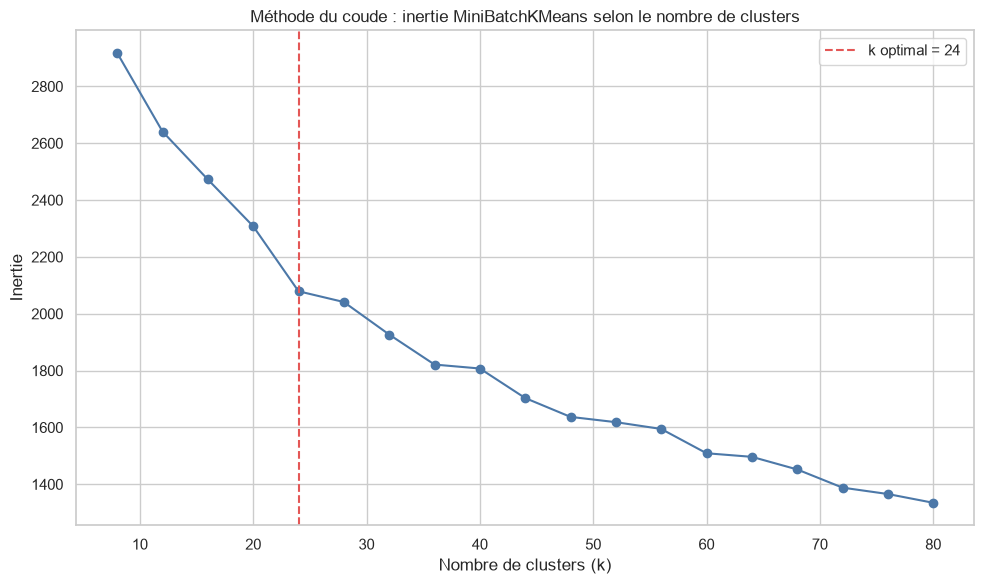

k optimal détecté par la méthode du coude : 24


Score de silhouette : 0.186
Le cluster -1 correspond aux motifs non exploitables ou non vectorisés.


,reason_raw,reason_model,cluster_id
0,Document scanné illisible,document scanne illisible,5
1,Absence d'audition du cédant (ou d'un référent qualifié) en cas d'achat ou don,absence d'audition cedant d'un referent qualifie cas d'achat don,11
2,"Absence de contrat, déclaration ou de preuve d'achat pour une cession réalisée avant le 14 octobre 2019",absence contrat declaration preuve d'achat cession realisee avant octobre,18
3,"Liste des servitudes insuffisamment renseignée (information manquante sur la nature, la localisation, le nom ou la caractérisation des détenteurs)",liste servitudes insuffisamment renseignee information_manquante nature localisation nom caracterisation detenteurs,19
4,"Absence signature d'un voisin ou son représentant sur le PVCL, avec absence du formulaire de carence de participation du voisin limitrophe concerné",absence signature d'un voisin representant pvcl absence formulaire carence participation voisin limitrophe concerne,0
5,Incohérence entre les noms des voisins inscrits sur le PVCL (PV des constats de limites) et le plan,incoherence entre noms voisins inscrits pvcl pv constats limites plan,22
6,"La qualité ""voisin"" des limitrophes sur la liste de présence du PVCL non mentionnée",qualite voisin limitrophes liste presence pvcl non mentionnee,0
7,Indication de piste comme limite d'une parcelle (indication de route avec emprise n'est pas un motif de rejet),indication piste comme limite d'une parcelle indication route emprise n'est pas motif,0
8,préciser les noms et qualités des personnes que les signataires des PVCL représentent,preciser noms qualites personnes signataires pvcl representent,0
9,Identifier le voisin situé entre les Bornes B1 et B7,identifier voisin situe entre bornes b1 b7,22


In [10]:
# Les motifs sont représentés par des vecteurs TF-IDF de n-grammes.
# Les motifs qui partagent des expressions proches sont regroupés dans
# un même cluster. Ces clusters servent ensuite à guider la revue métier.
#
# Le nombre de clusters n'est plus fixé arbitrairement : il est déterminé
# par la méthode du coude (courbe d'inertie MiniBatchKMeans, rapide même
# pour de nombreuses valeurs de k). Le vecteur TF-IDF est normalisé L2 par
# défaut, donc la distance euclidienne utilisée par KMeans est équivalente
# à la distance cosinus : ce balayage est donc cohérent avec le clustering
# final en cosinus. Une fois le k optimal détecté, le regroupement final
# reste réalisé par AgglomerativeClustering (cosinus, linkage average), qui
# donne de meilleurs clusters pour du texte que KMeans.

cluster_vectorizer = TfidfVectorizer(
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    sublinear_tf=True,
)

try:
    X = cluster_vectorizer.fit_transform(valid_texts)
except ValueError:
    cluster_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
    )
    X = cluster_vectorizer.fit_transform(valid_texts)

valid_indices = motifs.index[motifs["is_valid_reason"]].to_numpy()
non_zero_mask = np.asarray(X.sum(axis=1)).ravel() > 0

motifs["cluster_id"] = -1


def detect_elbow_k(k_values, inertias):
    """Trouve le point du coude : le k le plus éloigné de la droite reliant
    le premier et le dernier point de la courbe d'inertie normalisée."""
    k_values = np.asarray(k_values, dtype=float)
    inertias = np.asarray(inertias, dtype=float)

    if len(k_values) < 3:
        return int(k_values[0])

    k_range = k_values.max() - k_values.min()
    inertia_range = inertias.max() - inertias.min()

    k_norm = (k_values - k_values.min()) / k_range if k_range > 0 else k_values * 0
    inertia_norm = (
        (inertias - inertias.min()) / inertia_range if inertia_range > 0 else inertias * 0
    )

    start = np.array([k_norm[0], inertia_norm[0]])
    end = np.array([k_norm[-1], inertia_norm[-1]])
    line_vec = end - start
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    distances = []
    for x, y in zip(k_norm, inertia_norm):
        point_vec = np.array([x, y]) - start
        proj_length = np.dot(point_vec, line_vec_norm)
        proj_point = proj_length * line_vec_norm
        distances.append(np.linalg.norm(point_vec - proj_point))

    return int(k_values[int(np.argmax(distances))])


elbow_chart = None

if non_zero_mask.sum() >= 2:
    X_non_zero = X[non_zero_mask].toarray()
    indices_non_zero = valid_indices[non_zero_mask]
    n_samples = len(indices_non_zero)

    # -----------------------------------------
    # Méthode du coude : balayage de k et courbe d'inertie
    # -----------------------------------------
    k_max_valid = min(K_ELBOW_MAX, n_samples - 1)
    k_min_valid = min(K_ELBOW_MIN, k_max_valid)
    k_values = list(range(k_min_valid, k_max_valid + 1, K_ELBOW_STEP))

    if len(k_values) >= 3:
        inertias = []
        for k in k_values:
            kmeans_probe = MiniBatchKMeans(
                n_clusters=k,
                n_init=5,
                batch_size=1024,
                max_iter=200,
                random_state=42,
            )
            kmeans_probe.fit(X_non_zero)
            inertias.append(kmeans_probe.inertia_)

        optimal_k = detect_elbow_k(k_values, inertias)

        plt.figure(figsize=(10, 6))
        plt.plot(k_values, inertias, marker="o", color="#4c78a8")
        plt.axvline(optimal_k, color="#e45756", linestyle="--", label=f"k optimal = {optimal_k}")
        plt.title("Méthode du coude : inertie MiniBatchKMeans selon le nombre de clusters")
        plt.xlabel("Nombre de clusters (k)")
        plt.ylabel("Inertie")
        plt.legend()
        plt.tight_layout()
        elbow_chart = FIGURES_DIR / "coude_clusters.png"
        plt.savefig(elbow_chart, dpi=160, bbox_inches="tight")
        plt.show()

        print(f"k optimal détecté par la méthode du coude : {optimal_k}")
    else:
        # Pas assez de valeurs de k testables : on retombe sur le réglage manuel.
        optimal_k = min(max(2, N_CLUSTERS), n_samples)
        print(
            "Trop peu de motifs exploitables pour balayer la méthode du coude : "
            f"repli sur N_CLUSTERS = {optimal_k}."
        )

    actual_clusters = min(max(2, optimal_k), n_samples)

    clustering = AgglomerativeClustering(
        n_clusters=actual_clusters,
        metric="cosine",
        linkage="average",
    )

    labels = clustering.fit_predict(X_non_zero)
    motifs.loc[indices_non_zero, "cluster_id"] = labels

    if len(set(labels)) > 1 and len(labels) > len(set(labels)):
        silhouette = silhouette_score(X_non_zero, labels, metric="cosine")
        print(f"Score de silhouette : {silhouette:.3f}")
    else:
        silhouette = np.nan
else:
    optimal_k = np.nan
    silhouette = np.nan
    print("Pas assez de motifs exploitables pour créer des clusters.")

print("Le cluster -1 correspond aux motifs non exploitables ou non vectorisés.")
display(motifs[["reason_raw", "reason_model", "cluster_id"]].head(20))

In [11]:
# Cette table est destinée à la revue humaine.
# Elle montre les expressions principales et des exemples dans chaque cluster.

feature_names = cluster_vectorizer.get_feature_names_out()
cluster_rows = []

for cluster_id in sorted(motifs.loc[motifs["cluster_id"] >= 0, "cluster_id"].unique()):
    cluster_indices = motifs.index[motifs["cluster_id"].eq(cluster_id)]
    cluster_text_positions = [
        np.where(valid_indices == index)[0][0]
        for index in cluster_indices
        if index in valid_indices
    ]

    cluster_text_positions = [
        pos for pos in cluster_text_positions
        if non_zero_mask[pos]
    ]

    if not cluster_text_positions:
        continue

    cluster_matrix = X[cluster_text_positions]
    mean_weights = np.asarray(cluster_matrix.mean(axis=0)).ravel()

    top_terms = [
        feature_names[position]
        for position in mean_weights.argsort()[::-1][:10]
        if mean_weights[position] > 0
    ]

    cluster_motifs = motifs.loc[cluster_indices].copy()

    examples = " | ".join(
        cluster_motifs["reason_raw"]
        .dropna()
        .head(5)
        .astype(str)
        .tolist()
    )

    cluster_rows.append({
        "cluster_id": cluster_id,
        "motifs_count": len(cluster_motifs),
        "top_ngrams": " ; ".join(top_terms),
        "median_gap_days": cluster_motifs["gap_days"].median(),
        "main_regions": " ; ".join(
            cluster_motifs[REGION_COL]
            .value_counts()
            .head(3)
            .index.astype(str)
            .tolist()
        ),
        "main_operators": " ; ".join(
            cluster_motifs[OPERATOR_COL]
            .value_counts()
            .head(3)
            .index.astype(str)
            .tolist()
        ),
        "examples": examples,
    })

cluster_summary = (
    pd.DataFrame(cluster_rows)
    .sort_values("motifs_count", ascending=False)
    .reset_index(drop=True)
)

display(cluster_summary)

,cluster_id,motifs_count,top_ngrams,median_gap_days,main_regions,main_operators,examples
0,22,651,voisins ; absence ; voisins plan ; plan ; requises ; absence signatures requises ; signatures requises ; absence signatures ; signatures ; absence voisins,15.416667,GUEMON ; NAWA ; CAVALLY,GRP. TERRA VITAL ; CAB. TOPO BENHIBA ; GRP. CAG,Incohérence entre les noms des voisins inscrits sur le PVCL (PV des constats de limites) et le plan | Identifier le voisin situé entre les Bornes B1 et B7 | Incohérence entre les noms des voisins inscrits sur le PVCL et le plan | Enlever l'amorce...
1,11,379,referent ; absence audition ; audition ; absence ; absence audition referent ; audition referent ; qualifie ; referent qualifie ; cas ; declaration,29.000000,GUEMON ; CAVALLY ; NAWA,GRP. TERRA VITAL ; GRP. CAG ; CAB. TOPO BENHIBA,Absence d'audition du cédant (ou d'un référent qualifié) en cas d'achat ou don | Absence de déclaration du demandeur | Absence d’audition d’aumoins 1 référent qualifié | Absence audition d’au moins un référent qualifié (parents du demandeur) cas ...
2,7,346,enquete ; equipe ; equipe enquete ; membres ; membres equipe ; membres equipe enquete ; signature_absente ; signature_absente membres ; signature_absente membres equipe ; signature_absente certains membres,71.083333,CAVALLY ; GUEMON ; MORONOU,GRP. CAG ; GRP. TERRA VITAL ; CAB. TOPO BENHIBA,"equipe d'enquête incomplète et absence de signature des membres, à la question De qui le défunt détenait-il cette parcelle ? | PV RDC : Equipe d’enquête incomplète (absence du géomètre) | PV RDC : Absence de signature des voisins et du CVGFR | PV..."
3,2,288,date ; demande celle ; demande celle pvcl ; identiques ; pvcl identiques ; celle pvcl identiques ; date demande celle ; celle pvcl ; date demande ; demande,5.000000,NAWA ; CAVALLY ; PORO,CAB. TOPO BENHIBA ; GRP. CAG ; CGEDS,"Clarifier s'il s'agit d'une route ou piste et le voisin de l'autre côté de la piste | Absence de signature du géomètre, chefferie | Absence de signature du géomètre, chefferie | il y a des contradictions dans les auditions | Absence de signature ..."
4,0,282,voisin ; pas ; limitrophe ; voisin limitrophe ; est ; plan ; est pas ; figure pas ; pvcl ; figure,25.208333,CAVALLY ; TONKPI ; NAWA,GRP. CAG ; CAB. TOPO BENHIBA ; GRP. ALLIANCE IVOIR.,"Absence signature d'un voisin ou son représentant sur le PVCL, avec absence du formulaire de carence de participation du voisin limitrophe concerné | La qualité ""voisin"" des limitrophes sur la liste de présence du PVCL non mentionnée | Indication..."
5,1,241,plan situation ; situation ; plan ; ne ; pas ; constat ; certains ; ne pas ; superficie ; elements plan situation,63.291667,MORONOU ; GUEMON ; CAVALLY,GRP. ALLIANCE IVOIR. ; GRP. TERRA VITAL ; GRP. CAG,"la reponse ne peut etre un numero de telephone, absence d'audition d'un parent du demandeur, absence de l'equipe d'enqête au constat des limites,absence de la signature du demandeur sur le PV de constat de limites, absence des voisins au constat ..."
6,8,235,droits ; insuffisance ; parcelle ; information ; insuffisance information ; origine ; information droits ; insuffisance information droits ; origine droits ; insuffisance informations,28.041667,GUEMON ; MORONOU ; CAVALLY,GRP. TERRA VITAL ; GRP. ALLIANCE IVOIR. ; GRP. CAG,Insuffisance d’informations sur la nature des droits | Insuffisance d’informations sur l’origine des droits du demandeur | Insuffisance d'informations sur l'origine des droits coutumiers : plusieurs champs du questionnaire numero 3 sont vides | I...
7,4,180,champ_non_renseigne ; demographique ; fiche demographique ; fiche ; nationalite ; presence champ_non_renseigne ; champ_non_renseigne fiche ; champ_non_renseigne fiche demographique ; presence champ_non_renseigne fiche ; presence,70.875000,GUEMON ; CAVALLY ; MORONOU,GRP. TERRA VITAL ; GRP. CAG ; GRP. ALLIANCE IVOIR.,RDC : Le nom du gestionnaire apparait deux fois dans la fiche démographique | RDC : Le nom du gestionnaire apparait deux fois da

In [12]:
# Les clusters découvrent les formulations proches.
# La taxonomie métier donne ensuite des noms stables aux catégories.
#
# Les règles ci-dessous ont été étendues après deux passes de revue de
# cluster_summary et de motifs_a_revoir pour couvrir les familles de motifs
# répétitives qui n'étaient pas capturées par la première version.

THEME_TAXONOMY = [
    {
        "stable_theme": "signature_absente_ou_incomplete",
        "label": "Signature absente ou incomplète",
        "pattern": (
            r"signature_absente|signature_non_signee|"
            r"signature.*manquante|signataire|"
            r"absence.*signature|signature.*absence|non\s+sign"
        ),
    },
    {
        "stable_theme": "pvcl_constat_limites",
        "label": "PVCL et constats de limites",
        "pattern": r"\bpvcl\b|constat.*limite|limite.*plan",
    },
    {
        "stable_theme": "voisinage_limitrophes",
        "label": "Voisinage et limitrophes",
        "pattern": r"\bvoisin|voisine|limitrophe|famille|borne|amorce",
    },
    {
        "stable_theme": "plan_toponymie_noms",
        "label": "Plan, toponymie et noms",
        "pattern": (
            r"\bplan\b|toponymie|nom.*complet|incoherence.*nom|"
            r"circonscription|sous.?prefecture|ne\s+correspond|n'est pas correct|"
            r"legende|foret.*classee"
        ),
    },
    {
        "stable_theme": "pieces_documents_scan",
        "label": "Pièces et documents",
        "pattern": (
            r"document_a_fournir|document_a_joindre|piece_manquante|"
            r"\bdocument\b|\bscan|illisible|\bcni\b|contrat|declaration|"
            r"piece.*identit|carte.*identit|fiche.*demographique|"
            r"nationalite|numero.*piece"
        ),
    },
    {
        "stable_theme": "audition_enquete_historique",
        "label": "Audition, enquête et historique",
        "pattern": r"audition|enquete|referent|cedant|demandeur|historique.*parcelle",
    },
    {
        "stable_theme": "reponse_declarant_incoherente",
        "label": "Réponse ou déclarant incohérent",
        "pattern": (
            r"declarant.*faible|reponse.*fantaisiste|"
            r"incoherence.*declarant|declarant.*incoherent"
        ),
    },
    {
        "stable_theme": "gouvernance_designation_comite",
        "label": "Gouvernance, comité et désignation",
        "pattern": (
            r"comite.*villageois|chefferie|notabilite|"
            r"designation.*gestionnaire|gestionnaire.*designation|membre.*comite|"
            r"\bcvgfr\b|\bquota\b"
        ),
    },
    {
        "stable_theme": "droits_origine_transaction",
        "label": "Origine des droits et transaction",
        "pattern": r"origine.*droit|nature.*droit|transaction|succession|achat|don|cession",
    },
    {
        "stable_theme": "servitude_route_piste",
        "label": "Servitude, route et piste",
        "pattern": r"servitude|route|piste|emprise|chemin",
    },
    {
        "stable_theme": "shapefile_geometrie_superficie",
        "label": "Shapefile, géométrie et superficie",
        "pattern": r"shapefile|superficie|coordonne|geometr|polygon|parcelle",
    },
    {
        "stable_theme": "qualite_information_insuffisante",
        "label": "Information insuffisante ou à compléter",
        "pattern": (
            r"information_a_completer|information_a_preciser|"
            r"information_a_renseigner|information_manquante|"
            r"champ_non_renseigne|incomplet|insuffisan|"
            r"n'est pas.*renseigne|pas.*entierement.*renseigne|"
            r"ne figure pas|n'y figure pas|absence.*information|"
            r"absence.*requis|absence.*liste"
        ),
    },
]

# Après analyse de cluster_summary, renseigner ici les associations validées.
# Exemple : 4: "signature_absente_ou_incomplete"
# Garder ce dictionnaire vide lors du premier lancement.
CLUSTER_THEME_MAPPING = {
    # 0: "signature_absente_ou_incomplete",
    # 1: "pvcl_constat_limites",
}


def assign_theme_by_rule(text):
    """Attribue le premier thème dont la règle correspond au motif."""
    text = str(text)

    for theme in THEME_TAXONOMY:
        if re.search(theme["pattern"], text, flags=re.IGNORECASE):
            return theme["stable_theme"]

    return None


def assign_stable_theme(row):
    """
    Priorité :
    1. motif structurellement non exploitable (texte vide ou trop court) ;
    2. règle métier directe ;
    3. association manuelle validée entre cluster et thème ;
    4. autre_a_revoir.
    """
    if not row["is_valid_reason"]:
        return pd.Series({
            "stable_theme": "motif_non_exploitable",
            "theme_assignment_method": "non_exploitable",
            "needs_review": False,
        })

    rule_theme = assign_theme_by_rule(row["reason_model"])

    if rule_theme:
        return pd.Series({
            "stable_theme": rule_theme,
            "theme_assignment_method": "rule",
            "needs_review": False,
        })

    if row["cluster_id"] in CLUSTER_THEME_MAPPING:
        return pd.Series({
            "stable_theme": CLUSTER_THEME_MAPPING[row["cluster_id"]],
            "theme_assignment_method": "cluster_mapping",
            "needs_review": False,
        })

    return pd.Series({
        "stable_theme": "autre_a_revoir",
        "theme_assignment_method": "manual_review",
        "needs_review": True,
    })


motifs[["stable_theme", "theme_assignment_method", "needs_review"]] = motifs.apply(
    assign_stable_theme,
    axis=1,
)

taxonomy_df = pd.DataFrame(THEME_TAXONOMY)
taxonomy_df = pd.concat([
    taxonomy_df,
    pd.DataFrame([
        {
            "stable_theme": "motif_non_exploitable",
            "label": "Motif non exploitable (texte vide ou trop court)",
            "pattern": "is_valid_reason == False",
        },
        {
            "stable_theme": "autre_a_revoir",
            "label": "Autres motifs à revoir",
            "pattern": "Aucune règle ou correspondance de cluster validée",
        },
    ]),
], ignore_index=True)

display(motifs[[
    "reason_raw",
    "reason_model",
    "cluster_id",
    "stable_theme",
    "theme_assignment_method",
    "needs_review",
]].head(20))

,reason_raw,reason_model,cluster_id,stable_theme,theme_assignment_method,needs_review
0,Document scanné illisible,document scanne illisible,5,pieces_documents_scan,rule,False
1,Absence d'audition du cédant (ou d'un référent qualifié) en cas d'achat ou don,absence d'audition cedant d'un referent qualifie cas d'achat don,11,audition_enquete_historique,rule,False
2,"Absence de contrat, déclaration ou de preuve d'achat pour une cession réalisée avant le 14 octobre 2019",absence contrat declaration preuve d'achat cession realisee avant octobre,18,pieces_documents_scan,rule,False
3,"Liste des servitudes insuffisamment renseignée (information manquante sur la nature, la localisation, le nom ou la caractérisation des détenteurs)",liste servitudes insuffisamment renseignee information_manquante nature localisation nom caracterisation detenteurs,19,servitude_route_piste,rule,False
4,"Absence signature d'un voisin ou son représentant sur le PVCL, avec absence du formulaire de carence de participation du voisin limitrophe concerné",absence signature d'un voisin representant pvcl absence formulaire carence participation voisin limitrophe concerne,0,signature_absente_ou_incomplete,rule,False
5,Incohérence entre les noms des voisins inscrits sur le PVCL (PV des constats de limites) et le plan,incoherence entre noms voisins inscrits pvcl pv constats limites plan,22,pvcl_constat_limites,rule,False
6,"La qualité ""voisin"" des limitrophes sur la liste de présence du PVCL non mentionnée",qualite voisin limitrophes liste presence pvcl non mentionnee,0,pvcl_constat_limites,rule,False
7,Indication de piste comme limite d'une parcelle (indication de route avec emprise n'est pas un motif de rejet),indication piste comme limite d'une parcelle indication route emprise n'est pas motif,0,servitude_route_piste,rule,False
8,préciser les noms et qualités des personnes que les signataires des PVCL représentent,preciser noms qualites personnes signataires pvcl representent,0,signature_absente_ou_incomplete,rule,False
9,Identifier le voisin situé entre les Bornes B1 et B7,identifier voisin situe entre bornes b1 b7,22,voisinage_limitrophes,rule,False


In [13]:
# Cette étape mesure la couverture réelle de la taxonomie.
# Les motifs à revoir guideront les futures améliorations des règles.

theme_summary = (
    motifs.groupby("stable_theme", dropna=False)
    .agg(
        motifs_count=("reason_id", "count"),
        events_count=("event_id", "nunique"),
        median_gap_days=("gap_days", "median"),
        p90_gap_days=("gap_days", lambda values: values.quantile(0.90)),
        regions_count=(REGION_COL, "nunique"),
        operators_count=(OPERATOR_COL, "nunique"),
    )
    .reset_index()
)

theme_summary["motifs_pct"] = (
    theme_summary["motifs_count"] / len(motifs) * 100
).round(2)

theme_summary = theme_summary.sort_values(
    "motifs_count",
    ascending=False,
).reset_index(drop=True)

coverage_pct = (
    100
    - theme_summary.loc[
        theme_summary["stable_theme"].eq("autre_a_revoir"),
        "motifs_pct"
    ].sum()
)

motifs_to_review = motifs[
    motifs["needs_review"]
].sort_values(
    ["cluster_id", "reason_word_count"],
    ascending=[True, False],
)

print(f"Couverture de la taxonomie : {coverage_pct:.1f}%")
print(f"Motifs à revoir : {len(motifs_to_review):,}")

display(theme_summary)
display(motifs_to_review.head(50))

Couverture de la taxonomie : 97.2%
Motifs à revoir : 99


,stable_theme,motifs_count,events_count,median_gap_days,p90_gap_days,regions_count,operators_count,motifs_pct
0,signature_absente_ou_incomplete,760,490,16.916667,74.291667,9,6,21.27
1,pvcl_constat_limites,651,518,45.875000,79.458333,10,6,18.22
2,audition_enquete_historique,538,381,19.520833,69.666667,10,6,15.06
3,voisinage_limitrophes,488,368,54.250000,74.208333,10,6,13.66
4,pieces_documents_scan,482,336,51.125000,74.166667,10,6,13.49
5,plan_toponymie_noms,246,132,71.125000,74.208333,10,6,6.88
6,autre_a_revoir,99,79,17.041667,76.725000,8,6,2.77
7,qualite_information_insuffisante,91,91,55.541667,81.166667,7,6,2.55
8,shapefile_geometrie_superficie,86,80,25.520833,74.266667,8,6,2.41
9,droits_origine_transaction,69,67,71.083333,107.095833,8,6,1.93


,reason_id,event_id,source_row_id,reason_index,reason_raw,event_level,rejected_at,corrected_at,gap_days,Region,Nom Operateur Court,reason_clean,reason_model,reason_word_count,is_valid_reason,cluster_id,stable_theme,theme_assignment_method,needs_review
3572,3572,922,835,11,les PVOPUB et PVCPUB,N1,2026-06-15 10:53:00,2026-06-27 17:36:00,12.250000,TONKPI,CAB. TOPO BENHIBA,les pvopub et pvcpub,pvopub pvcpub,2,True,-1,autre_a_revoir,manual_review,True
2874,2874,678,591,5,la liste de présence n'est pas jointe à l'ouverture de la publicité,N1,2026-05-20 15:43:00,2026-06-16 10:44:00,26.791667,NAWA,CAB. TOPO BENHIBA,la liste de presence n'est pas jointe a l'ouverture de la publicite,liste presence n'est pas jointe l'ouverture publicite,7,True,0,autre_a_revoir,manual_review,True
2910,2910,691,604,3,la liste de présence n'est pas jointe à l'ouverture de la publicité,N1,2026-05-21 14:46:00,2026-06-16 10:44:00,25.791667,NAWA,CAB. TOPO BENHIBA,la liste de presence n'est pas jointe a l'ouverture de la publicite,liste presence n'est pas jointe l'ouverture publicite,7,True,0,autre_a_revoir,manual_review,True
2933,2933,696,609,3,la liste de présence n'est pas jointe à l'ouverture de la publicité,N1,2026-05-22 12:12:00,2026-06-16 10:44:00,24.916667,NAWA,CAB. TOPO BENHIBA,la liste de presence n'est pas jointe a l'ouverture de la publicite,liste presence n'est pas jointe l'ouverture publicite,7,True,0,autre_a_revoir,manual_review,True
2940,2940,698,611,4,la liste de présence n'est pas jointe à l'ouverture de la publicité,N1,2026-05-22 14:09:00,2026-06-16 10:45:00,24.833333,NAWA,CAB. TOPO BENHIBA,la liste de presence n'est pas jointe a l'ouverture de la publicite,liste presence n'est pas jointe l'ouverture publicite,7,True,0,autre_a_revoir,manual_review,True
3541,3541,902,815,2,La date des RDC est postérieure à celle de l'ouverture de publicité,N1,2026-06-08 16:19:00,2026-06-26 20:29:00,18.166667,TONKPI,CAB. TOPO BENHIBA,la date des rdc est posterieure a celle de l'ouverture de publicite,date rdc posterieure celle l'ouverture publicite,6,True,0,autre_a_revoir,manual_review,True
2999,2999,710,623,13,Qui est le représentant de la terre communautaire dans la liste de présence,N1,2026-06-08 14:26:00,2026-06-27 13:49:00,18.958333,N'ZI,GRP. 2ATY,qui est le representant de la terre communautaire dans la liste de presence,representant terre communautaire liste presence,5,True,0,autre_a_revoir,manual_review,True
1434,1434,230,186,2,Préciser comment il obtenu le bien,N1,2026-03-17 16:48:00,2026-06-03 14:19:00,77.875000,GUEMON,GRP. TERRA VITAL,preciser comment il obtenu le bien,preciser comment il obtenu,4,True,0,autre_a_revoir,manual_review,True
2951,2951,701,614,3,le CECPDC n'est pas disponible,N1,2026-05-22 19:32:00,2026-06-16 10:44:00,24.625000,NAWA,CAB. TOPO BENHIBA,le cecpdc n'est pas disponible,cecpdc n'est pas disponible,4,True,0,autre_a_revoir,manual_review,True
3462,3462,858,765,5,les signatures des déclarants 3 et 4 n'apparaissent pas,N1,2026-06-16 16:52:00,2026-06-30 11:36:00,13.750000,TONKPI,CAB. TOPO BENHIBA,les signatures des declarants 3 et 4 n'apparaissent pas,signatures declarants n'apparaissent pas,4,True,0,autre_a_revoir,manual_review,True


In [14]:
# Les tableaux suivants servent directement à l'analyse métier.

themes_by_region = pd.crosstab(
    motifs[REGION_COL],
    motifs["stable_theme"],
    normalize="index",
).mul(100).round(2)

themes_by_operator = pd.crosstab(
    motifs[OPERATOR_COL],
    motifs["stable_theme"],
    normalize="index",
).mul(100).round(2)

delay_by_region_operator = (
    motifs.groupby([REGION_COL, OPERATOR_COL])
    .agg(
        motifs_count=("reason_id", "count"),
        median_gap_days=("gap_days", "median"),
        p90_gap_days=("gap_days", lambda values: values.quantile(0.90)),
    )
    .reset_index()
    .sort_values("motifs_count", ascending=False)
)

motifs["rejected_month"] = (
    pd.to_datetime(motifs["rejected_at"], errors="coerce")
    .dt.to_period("M")
    .astype("string")
)

monthly_evolution = (
    motifs.groupby(["rejected_month", "stable_theme"], dropna=False)
    .agg(
        motifs_count=("reason_id", "count"),
        median_gap_days=("gap_days", "median"),
    )
    .reset_index()
    .sort_values(["rejected_month", "motifs_count"])
)

display(delay_by_region_operator.head(20))
display(themes_by_region)
display(themes_by_operator)
display(monthly_evolution.head(30))

,Region,Nom Operateur Court,motifs_count,median_gap_days,p90_gap_days
2,GUEMON,GRP. TERRA VITAL,1353,54.250000,81.166667
1,CAVALLY,GRP. CAG,779,73.041667,74.291667
7,NAWA,CAB. TOPO BENHIBA,458,4.041667,25.950000
5,MORONOU,GRP. ALLIANCE IVOIR.,337,52.833333,107.875000
10,TONKPI,CAB. TOPO BENHIBA,235,17.208333,42.541667
6,N'ZI,GRP. 2ATY,194,14.833333,21.933333
8,PORO,CGEDS,129,14.958333,29.475000
0,AGNEBY-TIASSA,GRP. ALLIANCE IVOIR.,49,53.166667,70.250000
3,LÔH-DJIBOUA,GRP. TERRA VITAL,20,37.145833,40.000000
9,TCHOLOGO,CGEDS,18,4.833333,10.925000


stable_theme,audition_enquete_historique,autre_a_revoir,droits_origine_transaction,gouvernance_designation_comite,motif_non_exploitable,pieces_documents_scan,plan_toponymie_noms,pvcl_constat_limites,qualite_information_insuffisante,reponse_declarant_incoherente,servitude_route_piste,shapefile_geometrie_superficie,signature_absente_ou_incomplete,voisinage_limitrophes
Region,,,,,,,,,,,,,,
AGNEBY-TIASSA,6.12,0.00,2.04,0.00,0.00,8.16,4.08,14.29,0.00,0.00,8.16,0.00,38.78,18.37
CAVALLY,3.47,2.05,2.57,0.51,0.00,13.09,21.05,15.28,0.39,0.00,0.00,2.57,19.90,19.13
GUEMON,22.39,1.18,1.70,0.52,0.00,13.53,3.47,18.40,5.10,0.30,0.07,1.85,13.45,18.03
LÔH-DJIBOUA,15.00,5.00,0.00,5.00,0.00,20.00,0.00,35.00,0.00,0.00,0.00,0.00,10.00,10.00
ME,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
MORONOU,26.41,4.15,5.34,0.00,0.00,11.57,5.04,28.49,0.30,0.00,0.00,1.78,9.79,7.12
N'ZI,10.82,14.95,0.52,3.61,0.00,20.62,1.03,8.76,0.52,0.00,9.28,2.58,12.89,14.43
NAWA,6.33,2.18,0.66,1.09,0.00,11.57,0.44,22.05,2.84,0.00,0.22,2.62,49.13,0.87
PORO,13.18,3.10,1.55,1.55,0.00,20.93,4.65,10.08,2.33,0.00,3.10,7.75,26.36,5.43


stable_theme,audition_enquete_historique,autre_a_revoir,droits_origine_transaction,gouvernance_designation_comite,motif_non_exploitable,pieces_documents_scan,plan_toponymie_noms,pvcl_constat_limites,qualite_information_insuffisante,reponse_declarant_incoherente,servitude_route_piste,shapefile_geometrie_superficie,signature_absente_ou_incomplete,voisinage_limitrophes
Nom Operateur Court,,,,,,,,,,,,,,
CAB. TOPO BENHIBA,9.96,2.74,0.58,0.87,0.14,11.40,0.72,20.06,2.02,0.29,0.29,2.74,44.73,3.46
CGEDS,15.65,2.72,1.36,1.36,0.00,21.09,5.44,11.56,2.04,0.00,2.72,7.48,23.13,5.44
GRP. 2ATY,10.77,14.87,0.51,3.59,0.00,20.51,1.54,8.72,0.51,0.00,9.23,2.56,12.82,14.36
GRP. ALLIANCE IVOIR.,23.83,3.63,4.92,0.00,0.00,11.14,4.92,26.68,0.26,0.00,1.04,1.55,13.47,8.55
GRP. CAG,3.47,2.05,2.57,0.51,0.00,13.09,21.05,15.28,0.39,0.00,0.00,2.57,19.90,19.13
GRP. TERRA VITAL,22.29,1.24,1.68,0.58,0.00,13.62,3.42,18.65,5.03,0.29,0.07,1.82,13.40,17.92


,rejected_month,stable_theme,motifs_count,median_gap_days
2,2026-02,qualite_information_insuffisante,1,115.000000
3,2026-02,signature_absente_ou_incomplete,1,101.208333
0,2026-02,audition_enquete_historique,2,115.000000
1,2026-02,pvcl_constat_limites,3,115.000000
7,2026-03,gouvernance_designation_comite,1,92.333333
12,2026-03,shapefile_geometrie_superficie,2,70.875000
9,2026-03,plan_toponymie_noms,8,78.937500
11,2026-03,qualite_information_insuffisante,9,83.875000
5,2026-03,autre_a_revoir,12,80.875000
6,2026-03,droits_origine_transaction,22,103.833333


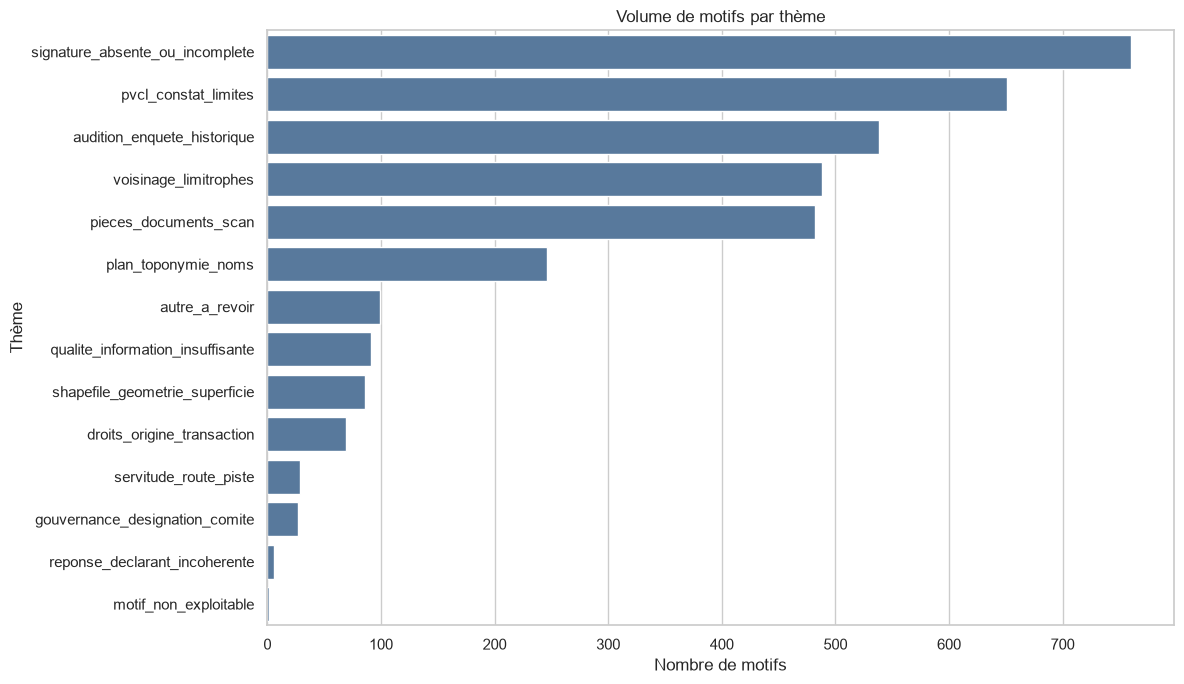

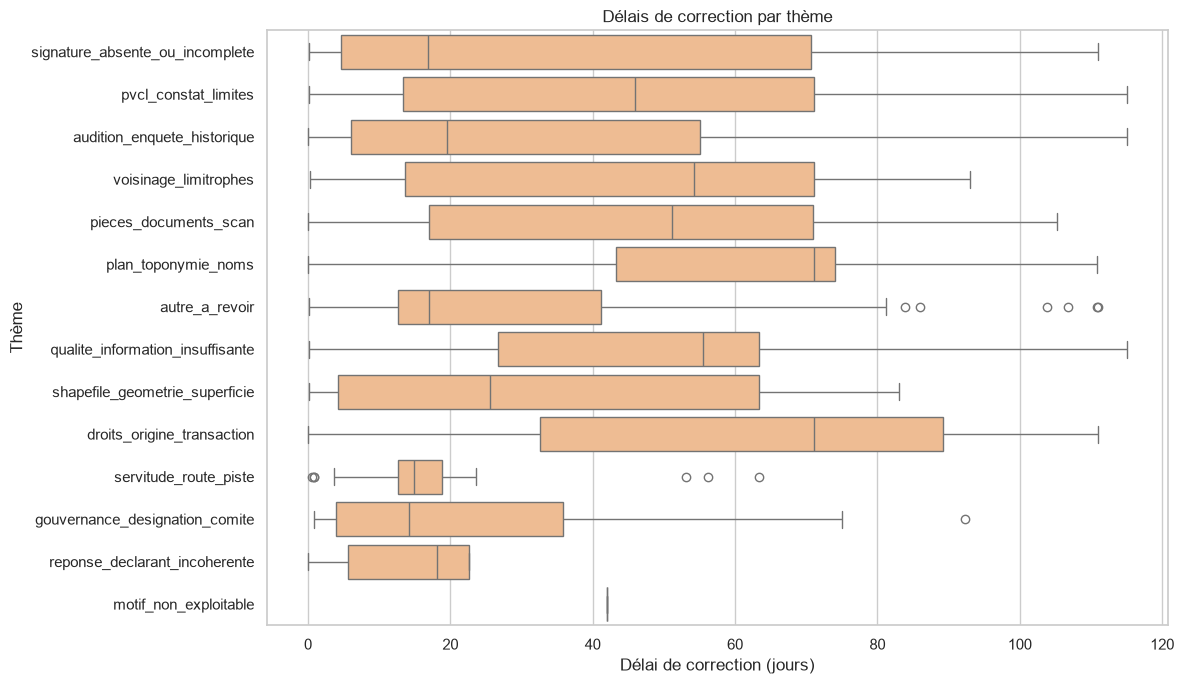

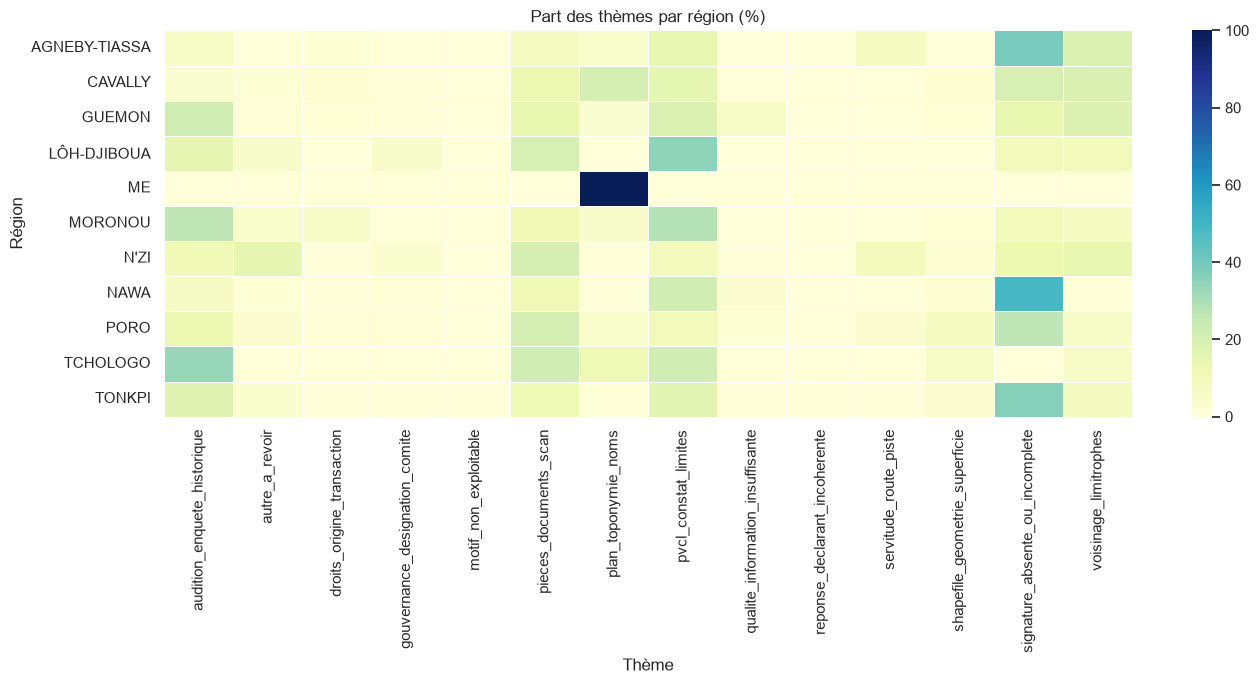

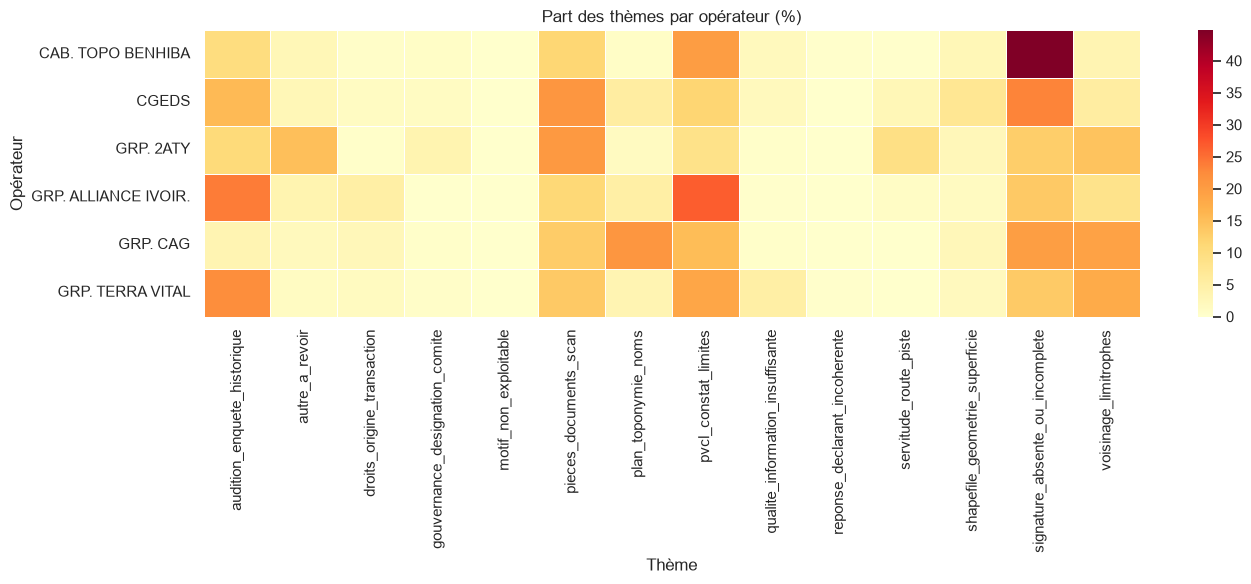

In [15]:
# Les graphiques sont affichés dans le notebook et enregistrés dans figures/.
# Ils seront aussi insérés dans le rapport Excel.

theme_order = theme_summary["stable_theme"].tolist()

plt.figure(figsize=(12, 7))
sns.barplot(
    data=theme_summary,
    x="motifs_count",
    y="stable_theme",
    order=theme_order,
    color="#4c78a8",
)
plt.title("Volume de motifs par thème")
plt.xlabel("Nombre de motifs")
plt.ylabel("Thème")
plt.tight_layout()
theme_volume_chart = FIGURES_DIR / "volume_par_theme.png"
plt.savefig(theme_volume_chart, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=motifs[motifs["stable_theme"].isin(theme_order)],
    x="gap_days",
    y="stable_theme",
    order=theme_order,
    color="#fdbb84",
)
plt.title("Délais de correction par thème")
plt.xlabel("Délai de correction (jours)")
plt.ylabel("Thème")
plt.tight_layout()
theme_delay_chart = FIGURES_DIR / "delais_par_theme.png"
plt.savefig(theme_delay_chart, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 7))
sns.heatmap(
    themes_by_region,
    cmap="YlGnBu",
    linewidths=0.4,
    linecolor="white",
)
plt.title("Part des thèmes par région (%)")
plt.xlabel("Thème")
plt.ylabel("Région")
plt.tight_layout()
region_heatmap_chart = FIGURES_DIR / "themes_par_region.png"
plt.savefig(region_heatmap_chart, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 6))
sns.heatmap(
    themes_by_operator,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
)
plt.title("Part des thèmes par opérateur (%)")
plt.xlabel("Thème")
plt.ylabel("Opérateur")
plt.tight_layout()
operator_heatmap_chart = FIGURES_DIR / "themes_par_operateur.png"
plt.savefig(operator_heatmap_chart, dpi=160, bbox_inches="tight")
plt.show()

In [16]:
# Cette étape crée le document final.
# Il contient les résultats détaillés, les contrôles qualité et les graphiques.

resume_executif = pd.DataFrame({
    "indicateur": [
        "Lignes source",
        "Événements extraits",
        "Motifs atomiques",
        "Motifs valides",
        "Motifs à revoir",
        "Couverture de la taxonomie (%)",
        "Nombre de clusters",
        "k optimal (méthode du coude)",
        "Score de silhouette",
    ],
    "valeur": [
        len(df),
        len(events),
        len(motifs),
        int(motifs["is_valid_reason"].sum()),
        len(motifs_to_review),
        round(coverage_pct, 2),
        int(motifs["cluster_id"].nunique() - (1 if -1 in motifs["cluster_id"].unique() else 0)),
        int(optimal_k) if pd.notna(optimal_k) else "Non calculé",
        round(silhouette, 3) if pd.notna(silhouette) else "Non calculé",
    ],
})

# Export CSVs utiles pour de futurs traitements ou pour ADAC.
events.to_csv(EVENTS_PATH, index=False, encoding="utf-8-sig")
motifs.to_csv(MOTIFS_PATH, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
    resume_executif.to_excel(writer, sheet_name="resume_executif", index=False)
    quality_data.to_excel(writer, sheet_name="qualite_donnees", index=False)
    motifs.to_excel(writer, sheet_name="motifs_details", index=False)
    theme_summary.to_excel(writer, sheet_name="themes_resume", index=False)
    cluster_summary.to_excel(writer, sheet_name="clusters", index=False)
    themes_by_region.reset_index().to_excel(
        writer,
        sheet_name="themes_par_region",
        index=False,
    )
    themes_by_operator.reset_index().to_excel(
        writer,
        sheet_name="themes_par_operateur",
        index=False,
    )
    delay_by_region_operator.to_excel(
        writer,
        sheet_name="delais_region_operateur",
        index=False,
    )
    monthly_evolution.to_excel(
        writer,
        sheet_name="evolution_mensuelle",
        index=False,
    )
    motifs_to_review.to_excel(
        writer,
        sheet_name="motifs_a_revoir",
        index=False,
    )
    taxonomy_df.to_excel(writer, sheet_name="taxonomie", index=False)
    ngram_counts.head(200).to_excel(
        writer,
        sheet_name="ngrams_frequents",
        index=False,
    )

# Ajout des graphiques dans une feuille dédiée.
workbook = load_workbook(REPORT_PATH)
worksheet = workbook.create_sheet("graphiques")

chart_positions = [
    (theme_volume_chart, "A1"),
    (theme_delay_chart, "A28"),
    (region_heatmap_chart, "J1"),
    (operator_heatmap_chart, "J28"),
    (elbow_chart, "A55"),
]

for image_path, anchor in chart_positions:
    if image_path is not None and image_path.exists():
        image = ExcelImage(str(image_path))
        image.width = 650
        image.height = 360
        worksheet.add_image(image, anchor)

# Mise en forme minimale : filtre, ligne d'en-tête figée et largeur adaptée.
for sheet_name in workbook.sheetnames:
    ws = workbook[sheet_name]

    if ws.max_row > 1:
        ws.auto_filter.ref = ws.dimensions
        ws.freeze_panes = "A2"

    for column_cells in ws.columns:
        column_letter = column_cells[0].column_letter
        max_length = max(
            len(str(cell.value)) if cell.value is not None else 0
            for cell in column_cells[:1000]
        )
        ws.column_dimensions[column_letter].width = min(max(max_length + 2, 12), 45)

workbook.save(REPORT_PATH)

print(f"Rapport Excel créé : {REPORT_PATH}")
print(f"Événements exportés : {EVENTS_PATH}")
print(f"Motifs détaillés exportés : {MOTIFS_PATH}")

Rapport Excel créé : ..\data\output\rapport_analyse_motifs_rejet.xlsx
Événements exportés : ..\data\output\rejection_events.csv
Motifs détaillés exportés : ..\data\output\rejection_reasons_detailed.csv


In [17]:
# Cette dernière cellule produit une synthèse rapide à lire après chaque exécution.

top_theme = theme_summary.iloc[0]
slowest_theme = (
    theme_summary
    .dropna(subset=["median_gap_days"])
    .sort_values("median_gap_days", ascending=False)
    .iloc[0]
)

print("SYNTHÈSE AUTOMATIQUE")
print("-" * 60)
print(
    f"Le thème le plus fréquent est "
    f"« {top_theme['stable_theme']} » "
    f"avec {top_theme['motifs_count']:,} motifs "
    f"({top_theme['motifs_pct']:.1f}%)."
)
print(
    f"Le thème au délai médian le plus élevé est "
    f"« {slowest_theme['stable_theme']} » "
    f"avec {slowest_theme['median_gap_days']:.1f} jours."
)
print(f"La couverture actuelle de la taxonomie est de {coverage_pct:.1f}%.")
print(
    f"{len(motifs_to_review):,} motifs sont dans "
    "« autre_a_revoir » et doivent être examinés pour améliorer les règles."
)

SYNTHÈSE AUTOMATIQUE
------------------------------------------------------------
Le thème le plus fréquent est « signature_absente_ou_incomplete » avec 760 motifs (21.3%).
Le thème au délai médian le plus élevé est « plan_toponymie_noms » avec 71.1 jours.
La couverture actuelle de la taxonomie est de 97.2%.
99 motifs sont dans « autre_a_revoir » et doivent être examinés pour améliorer les règles.
